# Explore here

In [ ]:
# Importamos las librerías necesarias para el proyecto
import requests  # para hacer peticiones a la API
import pandas as pd  # para trabajar con datos en formato tabla (DataFrame)
import matplotlib.pyplot as plt  # para hacer gráficos
import seaborn as sns  # para gráficos más visuales y fáciles
from sqlalchemy import create_engine  # para conectar con bases de datos SQL
from requests.adapters import HTTPAdapter  # para configurar reintentos en las peticiones
from urllib3.util.retry import Retry  # para definir cuántos reintentos hacer si falla la API

# Configuramos el estilo de los gráficos (más limpio y visual)
sns.set_theme(style="whitegrid")

# URL base de la API del World Bank
BASE_URL = "https://api.worldbank.org/v2"

# Tiempo máximo de espera para una petición (en segundos)
TIMEOUT = 60

# Creamos una sesión de requests para reutilizar conexiones (más eficiente)
session = requests.Session()

# Configuramos los reintentos en caso de error (por ejemplo si la API falla o tarda)
retry = Retry(
    total=5,  # número total de reintentos
    connect=5,  # reintentos si falla la conexión
    read=5,  # reintentos si falla la lectura de datos
    backoff_factor=1,  # tiempo de espera entre reintentos (aumenta progresivamente)
    status_forcelist=[429, 500, 502, 503, 504],  # errores por los que se reintenta
    allowed_methods=["GET"],  # solo se aplica a peticiones GET
)

# Aplicamos la configuración de reintentos a la sesión
session.mount("https://", HTTPAdapter(max_retries=retry))
session.mount("http://", HTTPAdapter(max_retries=retry))

In [ ]:
# Exploramos la API del World Bank para ver qué datos devuelve

# Construimos la URL para obtener información de países
url = f"{BASE_URL}/country"

# Definimos los parámetros de la petición
params = {
    "format": "json",   # queremos la respuesta en formato JSON
    "per_page": 50,     # número de resultados por página
    "page": 1,          # página que queremos consultar
}

# Hacemos la petición a la API usando la sesión configurada
response = session.get(url, params=params, timeout=TIMEOUT)

# Si hay un error (por ejemplo 404 o 500), lanza una excepción
response.raise_for_status()

# Convertimos la respuesta a formato JSON (diccionario/lista de Python)
payload = response.json()

# Mostramos los metadatos (información sobre paginación)
print("Pagination metadata:", payload[0])

# Mostramos el primer país para entender la estructura de los datos
print("First country record:", payload[1][0])

Pagination metadata: {'page': 1, 'pages': 6, 'per_page': '50', 'total': 296}
First country record: {'id': 'ABW', 'iso2Code': 'AW', 'name': 'Aruba', 'region': {'id': 'LCN', 'iso2code': 'ZJ', 'value': 'Latin America & Caribbean '}, 'adminregion': {'id': '', 'iso2code': '', 'value': ''}, 'incomeLevel': {'id': 'HIC', 'iso2code': 'XD', 'value': 'High income'}, 'lendingType': {'id': 'LNX', 'iso2code': 'XX', 'value': 'Not classified'}, 'capitalCity': 'Oranjestad', 'longitude': '-70.0167', 'latitude': '12.5167'}


In [ ]:
# Definimos los países con los que vamos a trabajar (códigos ISO3)
countries = ["ARG", "BRA", "CHL", "COL", "MEX"]

# Definimos los indicadores que queremos analizar
# (clave = código de la API, valor = nombre más entendible)
indicators = {
    "NY.GDP.PCAP.CD": "gdp_per_capita",   # PIB per cápita
    "SP.DYN.LE00.IN": "life_expectancy",  # esperanza de vida
    "SP.POP.TOTL": "population"           # población total
}

# Función para descargar datos de la API para uno o varios países e indicadores
def fetch_indicator_data(country_codes, indicator_id, start_year=2010, end_year=2024):
    
    # Unimos los países con ";" porque la API permite pedir varios a la vez
    country_path = ";".join(country_codes)
    
    # Construimos la URL completa del endpoint
    endpoint = f"{BASE_URL}/country/{country_path}/indicator/{indicator_id}"
    
    page = 1           # empezamos por la primera página
    all_rows = []      # aquí guardaremos todos los datos

    # Bucle para recorrer todas las páginas de la API
    while True:
        params = {
            "format": "json",                    # formato de salida
            "date": f"{start_year}:{end_year}",  # rango de años
            "per_page": 50,                     # número de resultados por página
            "page": page,                       # página actual
        }

        # Hacemos la petición
        response = session.get(endpoint, params=params, timeout=TIMEOUT)
        response.raise_for_status()

        # Convertimos a JSON
        payload = response.json()

        # Comprobamos que la respuesta tiene el formato esperado
        if not isinstance(payload, list) or len(payload) == 0:
            raise ValueError(f"Unexpected API response for {indicator_id}: {payload}")

        # metadata contiene info como número de páginas
        metadata = payload[0]

        # rows contiene los datos reales
        rows = payload[1] if len(payload) > 1 and payload[1] is not None else []

        # Añadimos los datos a la lista total
        all_rows.extend(rows)

        # Calculamos cuántas páginas hay en total
        total_pages = int(metadata.get("pages", 1))

        # Si ya hemos llegado a la última página, salimos del bucle
        if page >= total_pages:
            break

        # Si no, pasamos a la siguiente página
        page += 1

    # Devolvemos todos los datos recogidos
    return all_rows

In [ ]:
# Creamos un diccionario donde guardaremos un DataFrame por cada indicador
tables = {}

# Recorremos cada indicador definido anteriormente
for indicator_id, table_name in indicators.items():
    
    # Llamamos a la función para descargar los datos desde la API
    raw_rows = fetch_indicator_data(countries, indicator_id, 2010, 2024)

    # Mostramos cuántas filas se han descargado (para comprobar que funciona)
    print(f"{table_name}: filas descargadas = {len(raw_rows)}")

    # Lista donde guardaremos los datos limpios
    records = []

    # Recorremos cada fila de datos recibida de la API
    for row in raw_rows:
        
        # Si el valor es nulo, lo ignoramos (no nos interesa)
        if row.get("value") is None:
            continue

        # Guardamos solo las columnas que necesitamos
        records.append({
            "country": row["country"]["value"],  # nombre del país
            "year": row["date"],                # año
            "value": row["value"],              # valor del indicador
        })

    # Convertimos la lista en un DataFrame de pandas
    df = pd.DataFrame(records)

    # Si por alguna razón el DataFrame está vacío, lo indicamos y seguimos
    if df.empty:
        print(f"{table_name}: DataFrame vacío")
        continue

    # Convertimos las columnas a formato numérico
    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    # Eliminamos filas con valores nulos en year o value
    df = df.dropna(subset=["year", "value"]).copy()

    # Convertimos year a entero
    df["year"] = df["year"].astype(int)

    # Ordenamos los datos por país y año
    df = df.sort_values(["country", "year"]).reset_index(drop=True)

    # Guardamos el DataFrame en el diccionario con su nombre correspondiente
    tables[table_name] = df

# Mostramos las primeras filas del DataFrame de PIB per cápita
print(tables["gdp_per_capita"].head())

gdp_per_capita: filas descargadas = 75
life_expectancy: filas descargadas = 75
population: filas descargadas = 75
     country  year         value
0  Argentina  2010  10260.131311
1  Argentina  2011  12704.283182
2  Argentina  2012  12949.717487
3  Argentina  2013  12963.675773
4  Argentina  2014  12233.144412


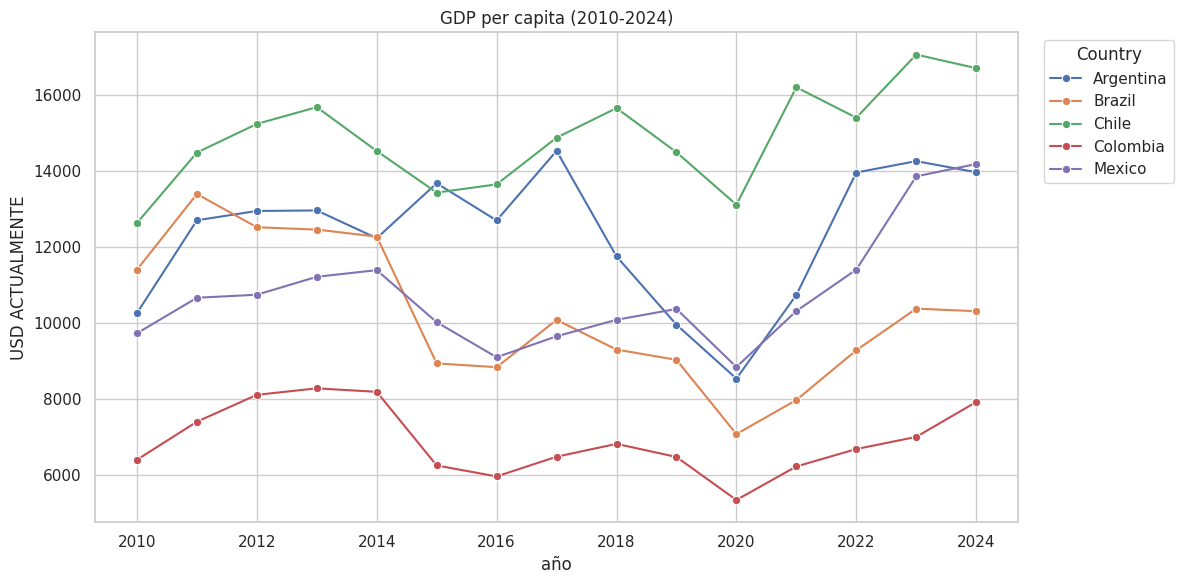

In [ ]:
# Visualizamos los datos con un gráfico de líneas

# Creamos una figura con tamaño personalizado
plt.figure(figsize=(12, 6))

# Gráfico de líneas:
# - x = año
# - y = valor del PIB per cápita
# - hue = separa por país (una línea por país)
sns.lineplot(
    data=tables["gdp_per_capita"],
    x="year",
    y="value",
    hue="country",
    marker="o"  # añade puntos en cada año
)

# Añadimos título al gráfico
plt.title("GDP per capita (2010-2024)")

# Etiquetas de los ejes
plt.xlabel("año")
plt.ylabel("USD ACTUALMENTE")

# Ajustamos la leyenda (la movemos fuera para que no tape el gráfico)
plt.legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left")

# Ajustamos el diseño para que no se solapen elementos
plt.tight_layout()

# Mostramos el gráfico
plt.show()

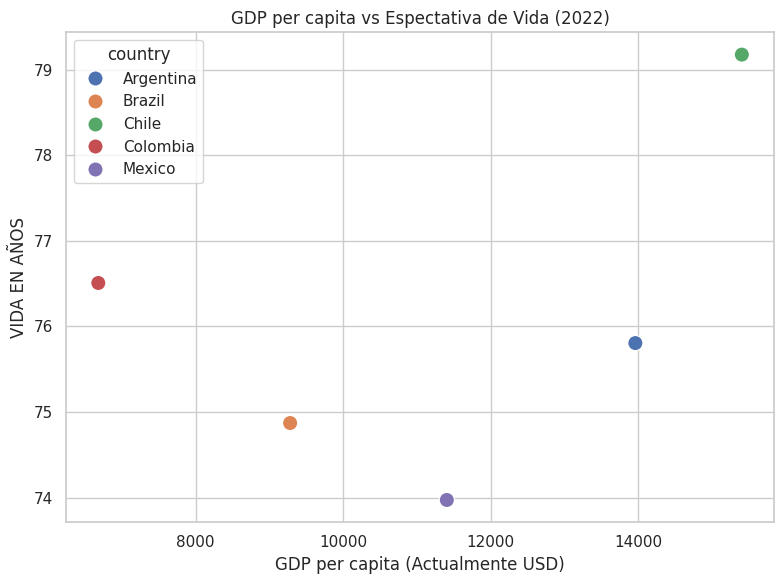

In [ ]:
# Ejemplo 2: relación entre PIB per cápita y esperanza de vida

# Elegimos el año que queremos analizar
latest_year = 2022

# Filtramos los datos de PIB per cápita para ese año
# y renombramos la columna "value" para que sea más clara
gdp_latest = tables["gdp_per_capita"] \
    .query("year == @latest_year") \
    .rename(columns={"value": "gdp_per_capita"})

# Hacemos lo mismo para la esperanza de vida
life_latest = tables["life_expectancy"] \
    .query("year == @latest_year") \
    .rename(columns={"value": "life_expectancy"})

# Unimos ambos DataFrames por el país
# para tener en la misma tabla PIB y esperanza de vida
merged = pd.merge(
    gdp_latest[["country", "gdp_per_capita"]],
    life_latest[["country", "life_expectancy"]],
    on="country",
    how="inner",
)

# Creamos un gráfico de dispersión 
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=merged,
    x="gdp_per_capita",       # eje X: PIB per cápita
    y="life_expectancy",      # eje Y: esperanza de vida
    hue="country",            # color por país
    s=120                     # tamaño de los puntos
)

# Título del gráfico
plt.title(f"GDP per capita vs Espectativa de Vida ({latest_year})")

# Etiquetas de los ejes
plt.xlabel("GDP per capita (Actualmente USD)")
plt.ylabel("VIDA EN AÑOS")

# Ajustamos el diseño
plt.tight_layout()

# Mostramos el gráfico
plt.show()

In [ ]:
# Importamos sqlite3 para trabajar con bases de datos SQLite
import sqlite3

# Creamos la conexión a la base de datos (si no existe, se crea automáticamente)
conn = sqlite3.connect("world_bank_analysis.db")

# Recorremos cada DataFrame almacenado en el diccionario tables
for table_name, df in tables.items():
    
    # Creamos un nombre de tabla más descriptivo
    sql_table_name = f"indicator_{table_name}"
    
    # Guardamos el DataFrame en la base de datos
    # if_exists="replace" significa que si la tabla ya existe, la sustituye
    df.to_sql(sql_table_name, conn, if_exists="replace", index=False)

# Comprobación: leemos una pequeña muestra de la base de datos
df_check = pd.read_sql("SELECT * FROM indicator_gdp_per_capita LIMIT 5", conn)

# Mostramos los datos para verificar que se han guardado correctamente
print(df_check)

# Cerramos la conexión a la base de datos
conn.close()

     country  year         value
0  Argentina  2010  10260.131311
1  Argentina  2011  12704.283182
2  Argentina  2012  12949.717487
3  Argentina  2013  12963.675773
4  Argentina  2014  12233.144412
